# EV Adoption Analysis in Ireland

This project aims to analyse and predict electric vehicle adoption trends based on factors such as fuel prices, incentives, and technological advancements.

In [2]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
print("Environment setup complete")

Environment setup complete


In [4]:
# Check versions 
print("Pandas version:", pd.__version__)
print("Numpy version:", np.__version__)

Pandas version: 2.2.2
Numpy version: 1.26.4


In [5]:
# Load datasets

ev_df = pd.read_excel('EVDataExplorer2025.xlsx')

fuel_df = pd.read_csv('CPM12.20260312T150355.csv')

transport_df = pd.read_csv('TEM12.20260312T150343.csv')

In [6]:
# Preview EV dataset
ev_df.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group
0,World,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,170000000.0,_World
1,World,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,150000000.0,_World
2,China,Projection-STEPS,EV stock,2 and 3 wheelers,BEV,2030,Vehicles,91000000.0,Other
3,China,Projection-STEPS,EV stock,Cars,BEV,2030,Vehicles,82000000.0,Other
4,World,Projection-STEPS,EV stock,Cars,PHEV,2030,Vehicles,82000000.0,_World


In [7]:
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16436 entries, 0 to 16435
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   region_country   16436 non-null  object 
 1   category         16436 non-null  object 
 2   parameter        16436 non-null  object 
 3   mode             16436 non-null  object 
 4   powertrain       16436 non-null  object 
 5   year             16436 non-null  int64  
 6   unit             16436 non-null  object 
 7   value            16436 non-null  float64
 8   Aggregate group  16436 non-null  object 
dtypes: float64(1), int64(1), object(7)
memory usage: 1.1+ MB


In [8]:
ev_df.describe()

,year,value
count,16436.000000,1.643600e+04
mean,2018.852336,2.678267e+05
std,4.271488,3.325613e+06
min,2010.000000,1.200000e-06
25%,2016.000000,1.000000e+00
50%,2019.000000,4.900000e+01
75%,2022.000000,2.500000e+03
max,2030.000000,1.700000e+08


In [9]:
ev_df.isnull().sum()

region_country     0
category           0
parameter          0
mode               0
powertrain         0
year               0
unit               0
value              0
Aggregate group    0
dtype: int64

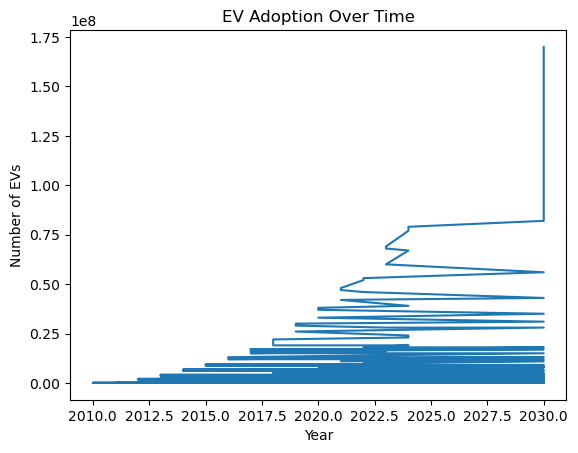

In [12]:
plt.plot(ev_df['year'], ev_df['value'])
plt.title('EV Adoption Over Time')
plt.xlabel('Year')
plt.ylabel('Number of EVs')
plt.show()

In [14]:
ireland_ev = ev_df[
    (ev_df['region_country'] == 'Ireland') &
    (ev_df['parameter'] == 'EV stock') &
    (ev_df['mode'] == 'Cars') &
    (ev_df['powertrain'] == 'BEV')
]

In [16]:
ireland_ev.head()

,region_country,category,parameter,mode,powertrain,year,unit,value,Aggregate group


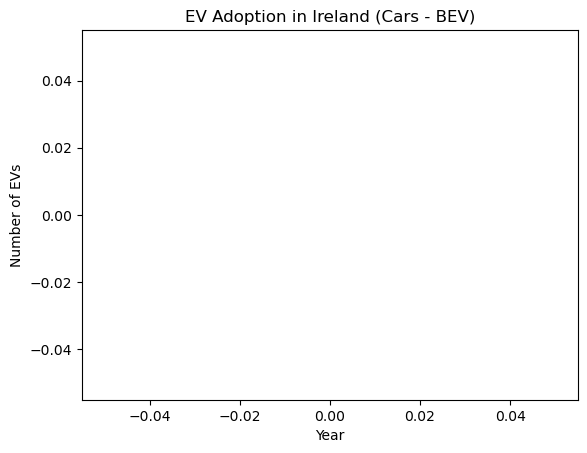

In [18]:
plt.plot(ireland_ev['year'], ireland_ev['value'])
plt.title('EV Adoption in Ireland (Cars - BEV)')
plt.xlabel('Year')
plt.ylabel('Number of EVs')
plt.show()

In [20]:
ev_df['region_country'].unique()

array(['World', 'China', 'Asia Pacific', 'India', 'Europe',
       'Rest of the world', 'USA', 'EU27', 'North America', 'Germany',
       'Viet Nam', 'United Kingdom', 'France', 'Norway', 'Canada',
       'Netherlands', 'Central and South America', 'Korea', 'Indonesia',
       'Sweden', 'Belgium', 'Denmark', 'Japan', 'Italy', 'Australia',
       'Turkiye', 'Spain', 'Switzerland', 'Austria', 'Israel', 'Thailand',
       'Finland', 'Portugal', 'Brazil', 'New Zealand',
       'Middle East and Caspian', 'Poland', 'Mexico', 'Malaysia',
       'Russia', 'Iceland', 'Greece', 'Uzbekistan', 'Africa', 'Ireland',
       'Chile', 'Costa Rica', 'Colombia', 'Romania', 'Luxembourg',
       'Czech Republic', 'Hungary', 'Slovenia', 'South Africa',
       'Slovakia', 'Lithuania', 'Bulgaria', 'Croatia', 'Latvia',
       'Estonia', 'Cyprus', 'Jordan', 'Seychelles'], dtype=object)

In [22]:
ev_df['parameter'].unique()

array(['EV stock', 'EV sales', 'EV charging points', 'Electricity demand',
       'Oil displacement, million lge', 'Battery demand',
       'EV sales share', 'EV stock share', 'Oil displacement Mbd'],
      dtype=object)

In [24]:
ev_df['mode'].unique()

array(['2 and 3 wheelers', 'Cars', 'Vans', 'EV', 'Trucks', 'Buses'],
      dtype=object)

In [26]:
ev_df['powertrain'].unique()

array(['BEV', 'PHEV', 'Publicly available slow',
       'Publicly available fast', 'EV', 'FCEV'], dtype=object)